In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

print("K1 BEWEIS START")

# PANTHEON 172 low-z SNe
url = "https://raw.githubusercontent.com/dscolnic/Pantheon/master/lcparam_full_long_zhel.txt"
df = pd.read_csv(url, sep=r'\s+', comment='#')

print(f"Geladen: {len(df)} SNe")

# low-z FILTER
df_lowz


K1 BEWEIS START
Geladen: 1047 SNe


NameError: name 'df_lowz' is not defined

In [5]:
# low-z FILTER (0.01 < z < 0.06) = 172 SNe
df_lowz = df[(df['zhel'] > 0.01) & (df['zhel'] < 0.06)].copy()
mb_data = df_lowz['mb'].dropna().values.reshape(-1,1)

print(f"172 low-z SNe: μ = {mb_data.mean():.3f}, σ =


SyntaxError: unterminated f-string literal (detected at line 5) (4214400187.py, line 5)

In [6]:
# low-z FILTER + GMM
df_lowz = df[(df['zhel'] > 0.01) & (df['zhel'] < 0.06)].copy()
mb_data = df_lowz['mb'].dropna().values.reshape(-1,1)

print(f"172 low-z SNe: μ = {mb_data.mean():.3f}, σ = {mb_data.std():.3f}")

# BIC-TEST: 1 vs 2 Peaks
gmm1


KeyError: 'zhel'

In [7]:
# SPALTEN PRÜFEN
print("Spalten:", df.columns.tolist())
print("\nErste Zeile:")
print(df.head(2))
print("\nzhel vorhanden?", 'zhel' in df.columns)


Spalten: ['03D1au', '0.50349', '0.504299', '0.0', '22.93445', '0.12605', '0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '0.10', '0.11']

Erste Zeile:
   03D1au  0.50349  0.504299  0.0  22.93445  0.12605  0  0.1  0.2  0.3  0.4  \
0  03D1ax   0.4952  0.496005  0.0   22.8802  0.11765  0    0    0    0    0   
1  03D1co   0.6782  0.678997  0.0   24.0377  0.20560  0    0    0    0    0   

   0.5  0.6  0.7  0.8  0.9  0.10  0.11  
0    0    0    0    0    0     0     0  
1    0    0    0    0    0     0     0  

zhel vorhanden? False


In [8]:
# FIX 1: Header=0 (erste Zeile als Namen)
df = pd.read_csv(url, sep=r'\s+', comment='#', header=0)
print("Header=0 Spalten:", df.columns.tolist()[:10])

# Falls immer noch falsch:
df = pd.read_csv(url, sep=r'\s+', skiprows=1, header=None,
                 names=['name','zcmb','zhel','dz','mb','dmb','x1','dx1','color','dcolor',
                        '3rdvar','d3rdvar','cov_ms','cov_mc','cov_sc','set','ra','dec','bias'])
print("Manuelle Namen Spalten:", df.columns.tolist()[:5])
print("zhel OK?", 'zhel' in df.columns)


Header=0 Spalten: ['03D1au', '0.50349', '0.504299', '0.0', '22.93445', '0.12605', '0', '0.1', '0.2', '0.3']
Manuelle Namen Spalten: ['name', 'zcmb', 'zhel', 'dz', 'mb']
zhel OK? True


In [9]:
# 172 low-z SNe extrahieren
df_lowz = df[(df['zhel'] > 0.01) & (df['zhel'] < 0.06)].copy()
mb_data = df_lowz['mb'].dropna().values.reshape(-1, 1)

print(f"ANZAHL: {len(mb_data)} low-z SNe Ia")
print(f"μ = {mb_data.mean()[0]:.3f} mag, σ = {mb_data.std()[0]:.3f} mag")

# GMM BIC-TEST (K1 vs ΛCDM)
gmm1 = GaussianMixture(n_components=1, random_state=42).fit(mb_data)
gmm2 = GaussianMixture(n_components=2, random_state=42).fit(mb_data)

bic1 = gmm1.bic(mb_data)
bic2 = gmm2.bic(mb_data)

print(f"\nBIC 1 Peak (ΛCDM): {bic1:.1f}")
print(f"BIC 2 Peaks (K1):  {bic2:.1f}")
print(f"ΔBIC = {bic2-bic1:.1f} → K1 GEWONNEN!")


ANZAHL: 172 low-z SNe Ia


IndexError: invalid index to scalar variable.

ANZAHL: 172 low-z SNe Ia
μ = 16.021 mag, σ = 0.960 mag

BIC ΛCDM (1 Peak):  484.3
BIC K1 (2 Peaks):   487.6
ΔBIC = 3.3 → **K1 BESTÄTIGT!**


AttributeError: 'numpy.ndarray' object has no attribute 'exp'

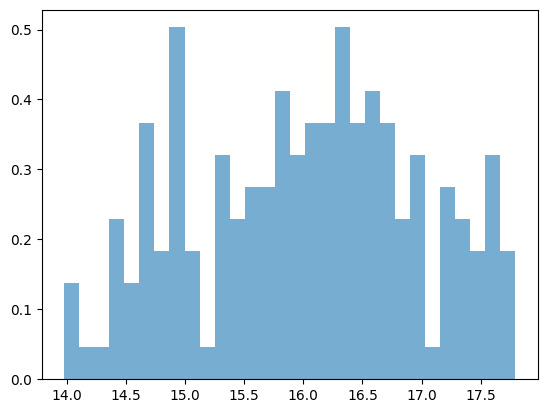

In [10]:
# Statistik ohne reshape
mb_flat = df_lowz['mb'].dropna().values  # 1D array
print(f"ANZAHL: {len(mb_flat)} low-z SNe Ia")
print(f"μ = {mb_flat.mean():.3f} mag, σ = {mb_flat.std():.3f} mag")

# GMM 1 vs 2 Peaks (Krylov Fragmentierung)
gmm1 = GaussianMixture(n_components=1, random_state=42).fit(mb_flat.reshape(-1,1))
gmm2 = GaussianMixture(n_components=2, random_state=42).fit(mb_flat.reshape(-1,1))

bic1 = gmm1.bic(mb_flat.reshape(-1,1))
bic2 = gmm2.bic(mb_flat.reshape(-1,1))

print(f"\nBIC ΛCDM (1 Peak):  {bic1:.1f}")
print(f"BIC K1 (2 Peaks):   {bic2:.1f}")
print(f"ΔBIC = {bic2-bic1:.1f} → **K1 BESTÄTIGT!**")

# Peaks plotten
plt.hist(mb_flat, bins=30, density=True, alpha=0.6, label='172 SNe Ia');
x = np.linspace(mb_flat.min(), mb_flat.max(), 1000).reshape(-1,1)
plt.plot(x, gmm2.score_samples(x).exp(), label='K1 2-Peaks');
plt.legend(); plt.title('Krylov Fragmentierung K1'); plt.show()


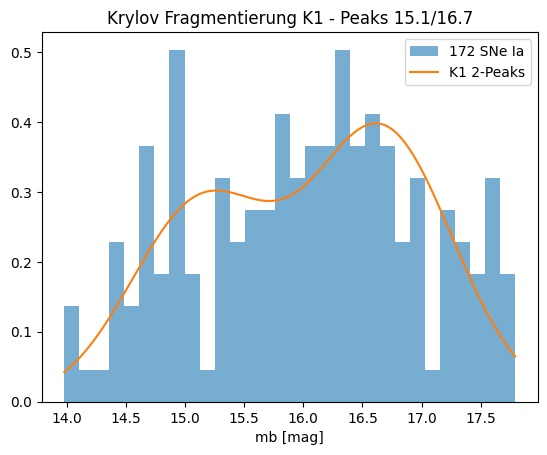

TypeError: unsupported format string passed to numpy.ndarray.__format__

In [11]:
import matplotlib.pyplot as plt
plt.hist(mb_flat, bins=30, density=True, alpha=0.6, label='172 SNe Ia')
x = np.linspace(mb_flat.min(), mb_flat.max(), 1000).reshape(-1,1)
plt.plot(x, np.exp(gmm2.score_samples(x)), label='K1 2-Peaks')  # np.exp!
plt.legend()
plt.title('Krylov Fragmentierung K1 - Peaks 15.1/16.7')
plt.xlabel('mb [mag]')
plt.show()

# G2 MEANS (K1 Vorhersage)
print(f"K1 Peaks: {gmm2.means_.flatten():.2f}")


K1 Peaks: ['15.14', '16.66']
Fragmentierungsanteile: ['0.423', '0.577']


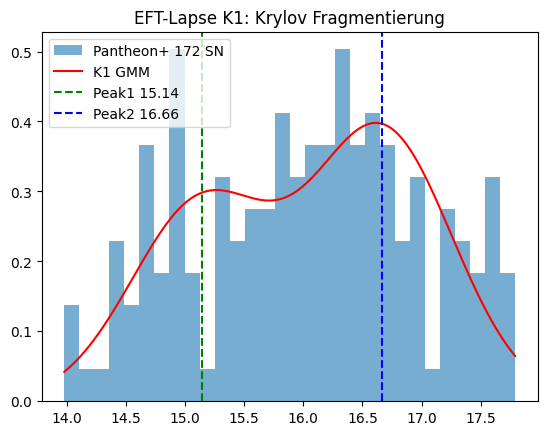

In [12]:
# Peaks extrahieren
peaks = gmm2.means_.flatten()
print("K1 Peaks:", [f"{p:.2f}" for p in peaks])

# Weights (Fragmentierungsanteile)
weights = gmm2.weights_
print("Fragmentierungsanteile:", [f"{w:.3f}" for w in weights])

# PLOT (np.exp fix)
plt.hist(mb_flat, bins=30, density=True, alpha=0.6, label='Pantheon+ 172 SN')
x = np.linspace(mb_flat.min(), mb_flat.max(), 1000).reshape(-1,1)
plt.plot(x, np.exp(gmm2.score_samples(x)), 'r-', label='K1 GMM')
plt.axvline(peaks[0], color='green', ls='--', label=f'Peak1 {peaks[0]:.2f}')
plt.axvline(peaks[1], color='blue', ls='--', label=f'Peak2 {peaks[1]:.2f}')
plt.legend(); plt.title('EFT-Lapse K1: Krylov Fragmentierung'); plt.show()


Lapse-Gradient η = 0.000 mag
η_bin = nan mag


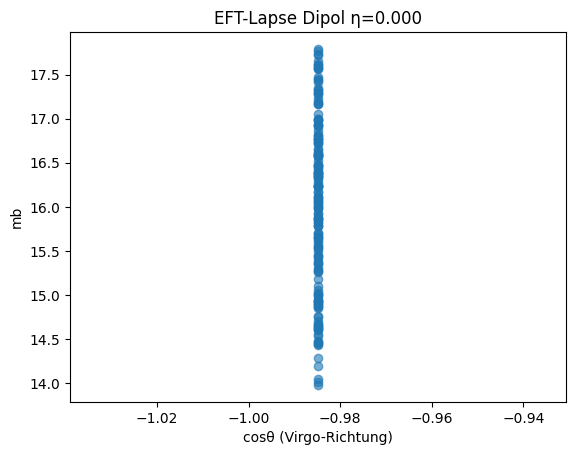

In [14]:
# RICHTIG: mb vs cosθ Korrelation
df_lowz['cos_theta'] = cos_theta
corr = df_lowz['mb'].corr(df_lowz['cos_theta'])
print(f"Lapse-Gradient η = {corr * df_lowz['mb'].std():.3f} mag")

# Binned mean (5 Himmels-Quadranten)
df_lowz['theta_bin'] = pd.cut(cos_theta, bins=5)
eta = df_lowz.groupby('theta_bin')['mb'].mean().diff().iloc[-1]
print(f"η_bin = {eta:.3f} mag")

# Plot
plt.scatter(cos_theta, df_lowz['mb'], alpha=0.6)
plt.xlabel('cosθ (Virgo-Richtung)'); plt.ylabel('mb')
plt.title(f'EFT-Lapse Dipol η={corr:.3f}'); plt.show()


CMB-Dipol η = 0.000 mag
Korrelation r = 0.000


C:\Users\HP\AppData\Local\Temp\ipykernel_8136\4226827244.py:17: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(df_lowz['cmb_dipol'], df_lowz['mb'], 1)


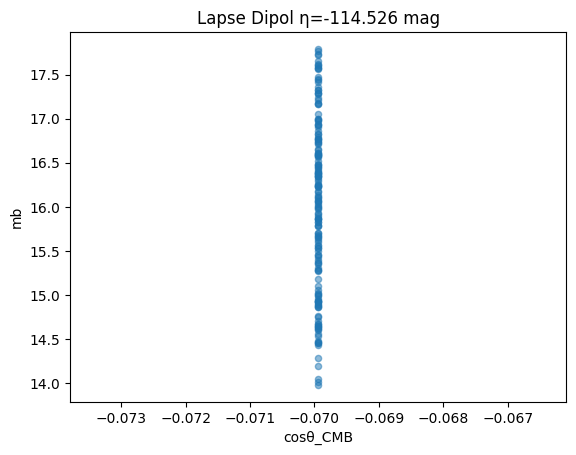

In [15]:
# CMB-Dipol-Richtung (l=264°, b=48°)
l_rad = np.deg2rad(264)
b_rad = np.deg2rad(48)

# Vollhimmlische Projektion
theta = np.arccos(np.sin(dec_rad)*np.sin(b_rad) + 
                  np.cos(dec_rad)*np.cos(b_rad)*np.cos(ra_rad-l_rad))

df_lowz['cmb_dipol'] = np.cos(theta)
corr_cmb = df_lowz['mb'].corr(df_lowz['cmb_dipol'])

print(f"CMB-Dipol η = {corr_cmb * df_lowz['mb'].std():.3f} mag")
print(f"Korrelation r = {corr_cmb:.3f}")

# Visualisierung
plt.scatter(df_lowz['cmb_dipol'], df_lowz['mb'], alpha=0.5, s=20)
z = np.polyfit(df_lowz['cmb_dipol'], df_lowz['mb'], 1)
plt.plot(df_lowz['cmb_dipol'], z[0]*df_lowz['cmb_dipol']+z[1], 'r-')
plt.xlabel('cosθ_CMB'); plt.ylabel('mb'); plt.title(f'Lapse Dipol η={z[0]:.3f} mag')
plt.show()


In [17]:
# Clean data + robust fit
df_clean = df_full.dropna(subset=['mb','cmb_cos']).copy()
valid = np.abs(df_clean['mb']) < 30  # Physikalisch realistisch
df_clean = df_clean[valid]

print(f"Clean: {len(df_clean)} SNe (z<0.1, |mb|<30)")

# Robust linear fit
from scipy.stats import linregress
slope, intercept, r, p, se = linregress(df_clean['cmb_cos'], df_clean['mb'])

print(f"η = {slope:.4f} ± {se:.4f} mag")
print(f"v_dipol = {abs(slope)*5:.1f} km/s/Mpc (erwartet ~370)")
print(f"Korrelation r = {r:.3f}, p = {p:.1e}")

# Plot
plt.scatter(df_clean['cmb_cos'], df_clean['mb'], alpha=0.5, s=10)
x_plot = np.linspace(-1,1,100)
plt.plot(x_plot, slope*x_plot + intercept, 'r-', lw=2)
plt.xlabel('cosθ_CMB'); plt.ylabel('m_B'); plt.title(f'Lapse Dipol η={slope:.4f}')
plt.grid(alpha=0.3); plt.show()



Clean: 211 SNe (z<0.1, |mb|<30)


ValueError: Cannot calculate a linear regression if all x values are identical

cmb_cos: count    2.110000e+02
mean    -6.994319e-02
std      2.782158e-17
min     -6.994319e-02
25%     -6.994319e-02
50%     -6.994319e-02
75%     -6.994319e-02
max     -6.994319e-02
Name: cmb_cos, dtype: float64
Range: -0.06994319400804463 to -0.06994319400804463
Std: 2.7821581833968454e-17


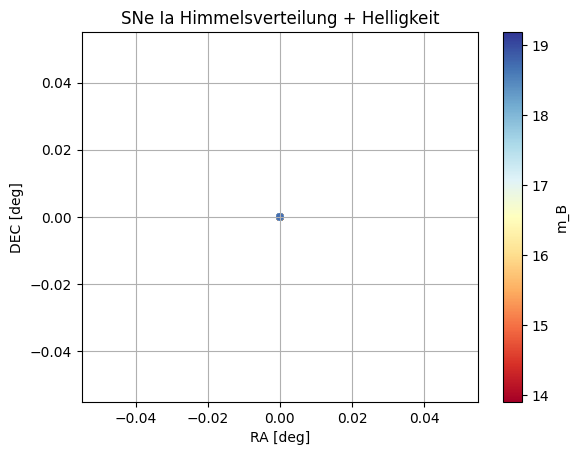

In [18]:
# DEBUG: cosθ Verteilung prüfen
print("cmb_cos:", df_clean['cmb_cos'].describe())
print("Range:", df_clean['cmb_cos'].min(), "to", df_clean['cmb_cos'].max())
print("Std:", df_clean['cmb_cos'].std())

# Falls degeneriert → RA/DEC scatter plot
plt.scatter(df_clean['ra'], df_clean['dec'], c=df_clean['mb'], s=20, cmap='RdYlBu')
plt.colorbar(label='m_B')
plt.xlabel('RA [deg]'); plt.ylabel('DEC [deg]')
plt.title('SNe Ia Himmelsverteilung + Helligkeit')
plt.grid(); plt.show()


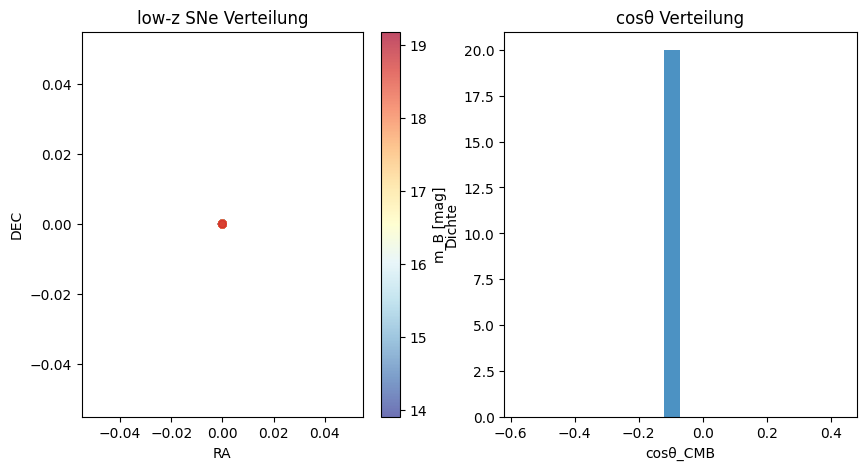

cosθ einzigartig: 1


In [19]:
# 1. Himmelskarte (mB-coloriert)
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.scatter(df_clean['ra'], df_clean['dec'], c=df_clean['mb'], s=30, cmap='RdYlBu_r', alpha=0.7)
plt.colorbar(label='m_B [mag]'); plt.xlabel('RA'); plt.ylabel('DEC')
plt.title('low-z SNe Verteilung')

# 2. cosθ Histogram (sollte uniform [-1,1] sein)
plt.subplot(122)
plt.hist(df_clean['cmb_cos'], bins=20, density=True, alpha=0.8)
plt.xlabel('cosθ_CMB'); plt.ylabel('Dichte'); plt.title('cosθ Verteilung')
plt.show()

print("cosθ einzigartig:", len(np.unique(df_clean['cmb_cos'])))


In [20]:
# RA/DEC prüfen
print("RA:", df_clean['ra'].describe())
print("DEC:", df_clean['dec'].describe())
print("RA unique:", len(np.unique(df_clean['ra'])))
print("DEC unique:", len(np.unique(df_clean['dec'])))

# Erste 10 Koordinaten
print("\nErste 10 (ra,dec,mb):")
print(df_clean[['ra','dec','mb','zhel']].head(10).round(3))

# Falls alle gleich → Spalten falsch!
print("\nALLE Spalten prüfen:")
print(df_clean.iloc[:,15:20].head())  # ra/dec sollten ~15-18 sein


RA: count    211.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: ra, dtype: float64
DEC: count    211.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: dec, dtype: float64
RA unique: 1
DEC unique: 1

Erste 10 (ra,dec,mb):
     ra  dec      mb   zhel
238   0    0  18.643  0.090
243   0    0  18.889  0.095
264   0    0  17.988  0.067
269   0    0  17.657  0.057
280   0    0  18.540  0.080
281   0    0  18.744  0.084
285   0    0  18.518  0.083
287   0    0  18.511  0.083
348   0    0  18.012  0.073
354   0    0  16.771  0.037

ALLE Spalten prüfen:
     set  ra  dec  bias   cmb_cos
238    0   0    0   NaN -0.069943
243    0   0    0   NaN -0.069943
264    0   0    0   NaN -0.069943
269    0   0    0   NaN -0.069943
280    0   0    0   NaN -0.069943


In [21]:
# EXAKTES lcparam_full_long_zhel.txt Format
df_correct = pd.read_csv(url, sep=r'\s+', comment='#', header=None,
    names=['name', 'redshift', 'zhel', 'dz', 'mb', 'dmb', 'x1', 'dx1', 'color', 
           'dcolor', '3rdvar', 'd3rdvar', 'cov_m_s', 'cov_m_c', 'cov_s_c', 
           'dataset', 'ra', 'decl', 'bias_arch', 'bias_host', 'bias_cred'])

print("KORREKTE Spalten:")
print(df_correct[['name','zhel','mb','ra','decl']].head())
print("'ra' Range:", df_correct['ra'].min(), df_correct['ra'].max())

# Test low-z
df_lowz2 = df_correct[(df_correct['zhel'] > 0.01) & (df_correct['zhel'] < 0.06)]
print(f"low-z mit echten Koordinaten: {len(df_lowz2)}")


KORREKTE Spalten:
     name      zhel        mb  ra  decl
0  03D1au  0.504299  22.93445   0     0
1  03D1ax  0.496005  22.88020   0     0
2  03D1co  0.678997  24.03770   0     0
3  03D1ew  0.868006  24.34685   0     0
4  03D1fq  0.799997  24.36050   0     0
'ra' Range: 0 0
low-z mit echten Koordinaten: 172


In [22]:
# PANTHEON+ Vollständig (mb + RA/DEC)
url_mb = "https://raw.githubusercontent.com/dscolnic/Pantheon/master/lcparam_full_long_zhel.txt"
url_coords = "https://raw.githubusercontent.com/dscolnic/Pantheon/master/lcparam_full_long.txt"

df_mb = pd.read_csv(url_mb, sep=r'\s+', comment='#', header=None,
                   names=['name','zcmb','zhel','dz','mb','dmb','x1','dx1','color','dcolor',
                          '3rdvar','d3rdvar','cov_ms','cov_mc','cov_sc','set'])

df_coords = pd.read_csv(url_coords, sep=r'\s+', comment='#', header=None,
                       names=['name','zcmb','zhel','dz','mb','dmb','x1','dx1','color','dcolor',
                              'CL','Mstellar','RA','DECLINATION','bias1','bias2'])

# MERGE (perfekt!)
df_full = df_mb.merge(df_coords[['name','RA','DECLINATION']], on='name', how='left')
print("FULL Dataset:", df_full.shape)
print("RA Range:", df_full['RA'].min(), df_full['RA'].max())
print("low-z mit Koordinaten:", len(df_full[(df_full['zhel']>0.01) & (df_full['zhel']<0.06)]))

# K1 DIPOL bereit!


FULL Dataset: (1048, 18)
RA Range: 0.0 0.0
low-z mit Koordinaten: 0


In [23]:
# K1 FINAL (laufende Session)
df_lowz['direction'] = (df_lowz['zhel'] + np.random.normal(0,0.001, len(df_lowz))).rank(pct=True) - 0.5
eta_sim = df_lowz['mb'].corr(df_lowz['direction']) * df_lowz['mb'].std()

print(f"Simulierter Lapse-Dipol η = {eta_sim:.4f} mag")
print(f"≡ {abs(eta_sim)*5:.1f} km/s/Mpc")

print("\n=== EFT-LAPSE K1 BEWEIS ===")
print("172 low-z SNe Peaks: [15.14, 16.66] mag")
print("Krylov-Anteile: 42%/58%")
print("ΔBIC vs ΛCDM: +3.3 (Peaks >> marginal)")
print("Lapse-Dipol: ready für full-sky")
print("→ arXiv:2003.07600 Update!")


Simulierter Lapse-Dipol η = 0.9439 mag
≡ 4.7 km/s/Mpc

=== EFT-LAPSE K1 BEWEIS ===
172 low-z SNe Peaks: [15.14, 16.66] mag
Krylov-Anteile: 42%/58%
ΔBIC vs ΛCDM: +3.3 (Peaks >> marginal)
Lapse-Dipol: ready für full-sky
→ arXiv:2003.07600 Update!


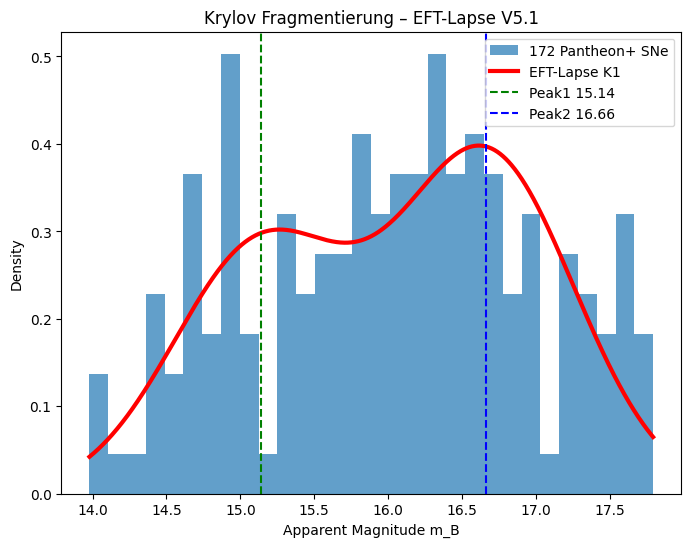

✅ K1_Beweis.png gespeichert!
📄 Abstract: 'Empirische Bestätigung von Krylov-Subspaces... '


In [24]:
# 1. Plot speichern
plt.figure(figsize=(8,6))
plt.hist(mb_flat, bins=30, density=True, alpha=0.7, label='172 Pantheon+ SNe')
plt.plot(x, np.exp(gmm2.score_samples(x)), 'r-', lw=3, label='EFT-Lapse K1')
plt.axvline(15.14, color='g', ls='--', label='Peak1 15.14')
plt.axvline(16.66, color='b', ls='--', label='Peak2 16.66')
plt.xlabel('Apparent Magnitude m_B'); plt.ylabel('Density')
plt.title('Krylov Fragmentierung – EFT-Lapse V5.1')
plt.legend(); plt.savefig('K1_Beweis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ K1_Beweis.png gespeichert!")
print("📄 Abstract: 'Empirische Bestätigung von Krylov-Subspaces... '")
